# Compound Lens — Direct Fit

## Learning to Autolens / Examples / compound_lens

---

**Problem.** A single source at **z = 1.7** is deflected by **two foreground galaxies**, the first at z = 0.5 and the second at z = 0.8. This is a *compound* lens: the ray from the source passes through the z = 0.8 deflector, then the z = 0.5 deflector, then the observer. `al.Tracer` handles the recursive plane-to-plane ray-tracing automatically once you hand it galaxies at three different redshifts.

**Method.** A single free-fit with `af.Nautilus` + curated, truth-seeded priors. This is the *direct* approach — we build a 2-lens + 1-source model all at once and let Nautilus find the joint posterior. Compare against `02_compound_slam.ipynb` for the staged-chain alternative.

**Prerequisites.**
- Mod 03 (single free fit with Nautilus)
- Mod 04 (SLaM + prior-seeding intuition)
- Mod 11 (what a physical mass model looks like; this notebook ends with a Mod-11-style skill audit)

**Key references.**
- Multi-plane ray-tracing theory: Schneider, Ehlers & Falco 1992 Ch. 9; Keeton (2003) arXiv:astro-ph/0102340.
- `autolens_workspace_latest/scripts/guides/advanced/multi_plane.py` — the canonical `al.Tracer` multi-plane API.
- `autolens_workspace_latest/scripts/imaging/features/extra_galaxies/modeling.py` — fixed-centre multi-galaxy modelling.

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import os
if os.environ.get("PYAUTOFIT_TEST_MODE"):
    raise RuntimeError(
        f"PYAUTOFIT_TEST_MODE={os.environ['PYAUTOFIT_TEST_MODE']!r} is set. "
        "Unset it and restart the kernel: unset PYAUTOFIT_TEST_MODE"
    )

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, IFrame, Markdown, display

import autofit as af
import autolens as al
import autolens.plot as aplt

%matplotlib inline
print(f"PyAutoLens version: {al.__version__}")

PyAutoLens version: 2026.4.13.6


In [2]:
# ============================================================
# HELPER: show_result() — load the committed Cannon artifact
# ============================================================
# Mirrors the Mod 04/05 pattern. Reads summary.json + fit_subplot.png
# + corner.pdf + model_results.txt from results/<stage>/.
# ============================================================
RESULTS_ROOT = Path("results")

def show_result(stage_name):
    stage_dir = RESULTS_ROOT / stage_name
    if not stage_dir.exists():
        print(f"(no results for stage {stage_name!r} yet — run on Cannon or set LTA_RUN_HEAVY=1)")
        return

    summary_path = stage_dir / "summary.json"
    if summary_path.exists():
        summary = json.loads(summary_path.read_text())
        display(Markdown(
            f"### `{stage_name}`\n"
            f"- max log-likelihood: **{summary.get('max_log_likelihood'):.2f}**\n"
            f"- log evidence: **{summary.get('log_evidence'):.2f}**\n"
            f"- χ²/N = **{summary.get('chi_squared_per_pixel'):.3f}** "
            f"({summary.get('chi_squared_total'):.0f} / {summary.get('n_unmasked_pixels')} unmasked px)\n"
            f"- max |normalized residual| = **{summary.get('max_abs_normalized_residual'):.2f} σ**"
        ))

    fit_png = stage_dir / "fit_subplot.png"
    if fit_png.exists():
        display(Markdown("**Fit subplot:**"))
        display(Image(filename=str(fit_png)))

    corner_pdf = stage_dir / "corner.pdf"
    if corner_pdf.exists():
        display(Markdown("**Corner plot:**"))
        display(IFrame(src=str(corner_pdf), width=720, height=720))

    mr = stage_dir / "model_results.txt"
    if mr.exists():
        preview = "\n".join(mr.read_text().splitlines()[:40])
        display(Markdown(f"**`model_results.txt`** (first 40 lines):\n\n```\n{preview}\n```"))

---

## 1. Load the data

The mocks are simulated with `pixel_scales=0.05"` (HST-like sampling). The noise map is the image times 3% plus a small Gaussian floor — whatever the exact recipe, the `al.Imaging.from_fits` loader just consumes the three FITS files and we don't need to know more.

2026-04-22 10:45:27,477 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 9176 image-pixels


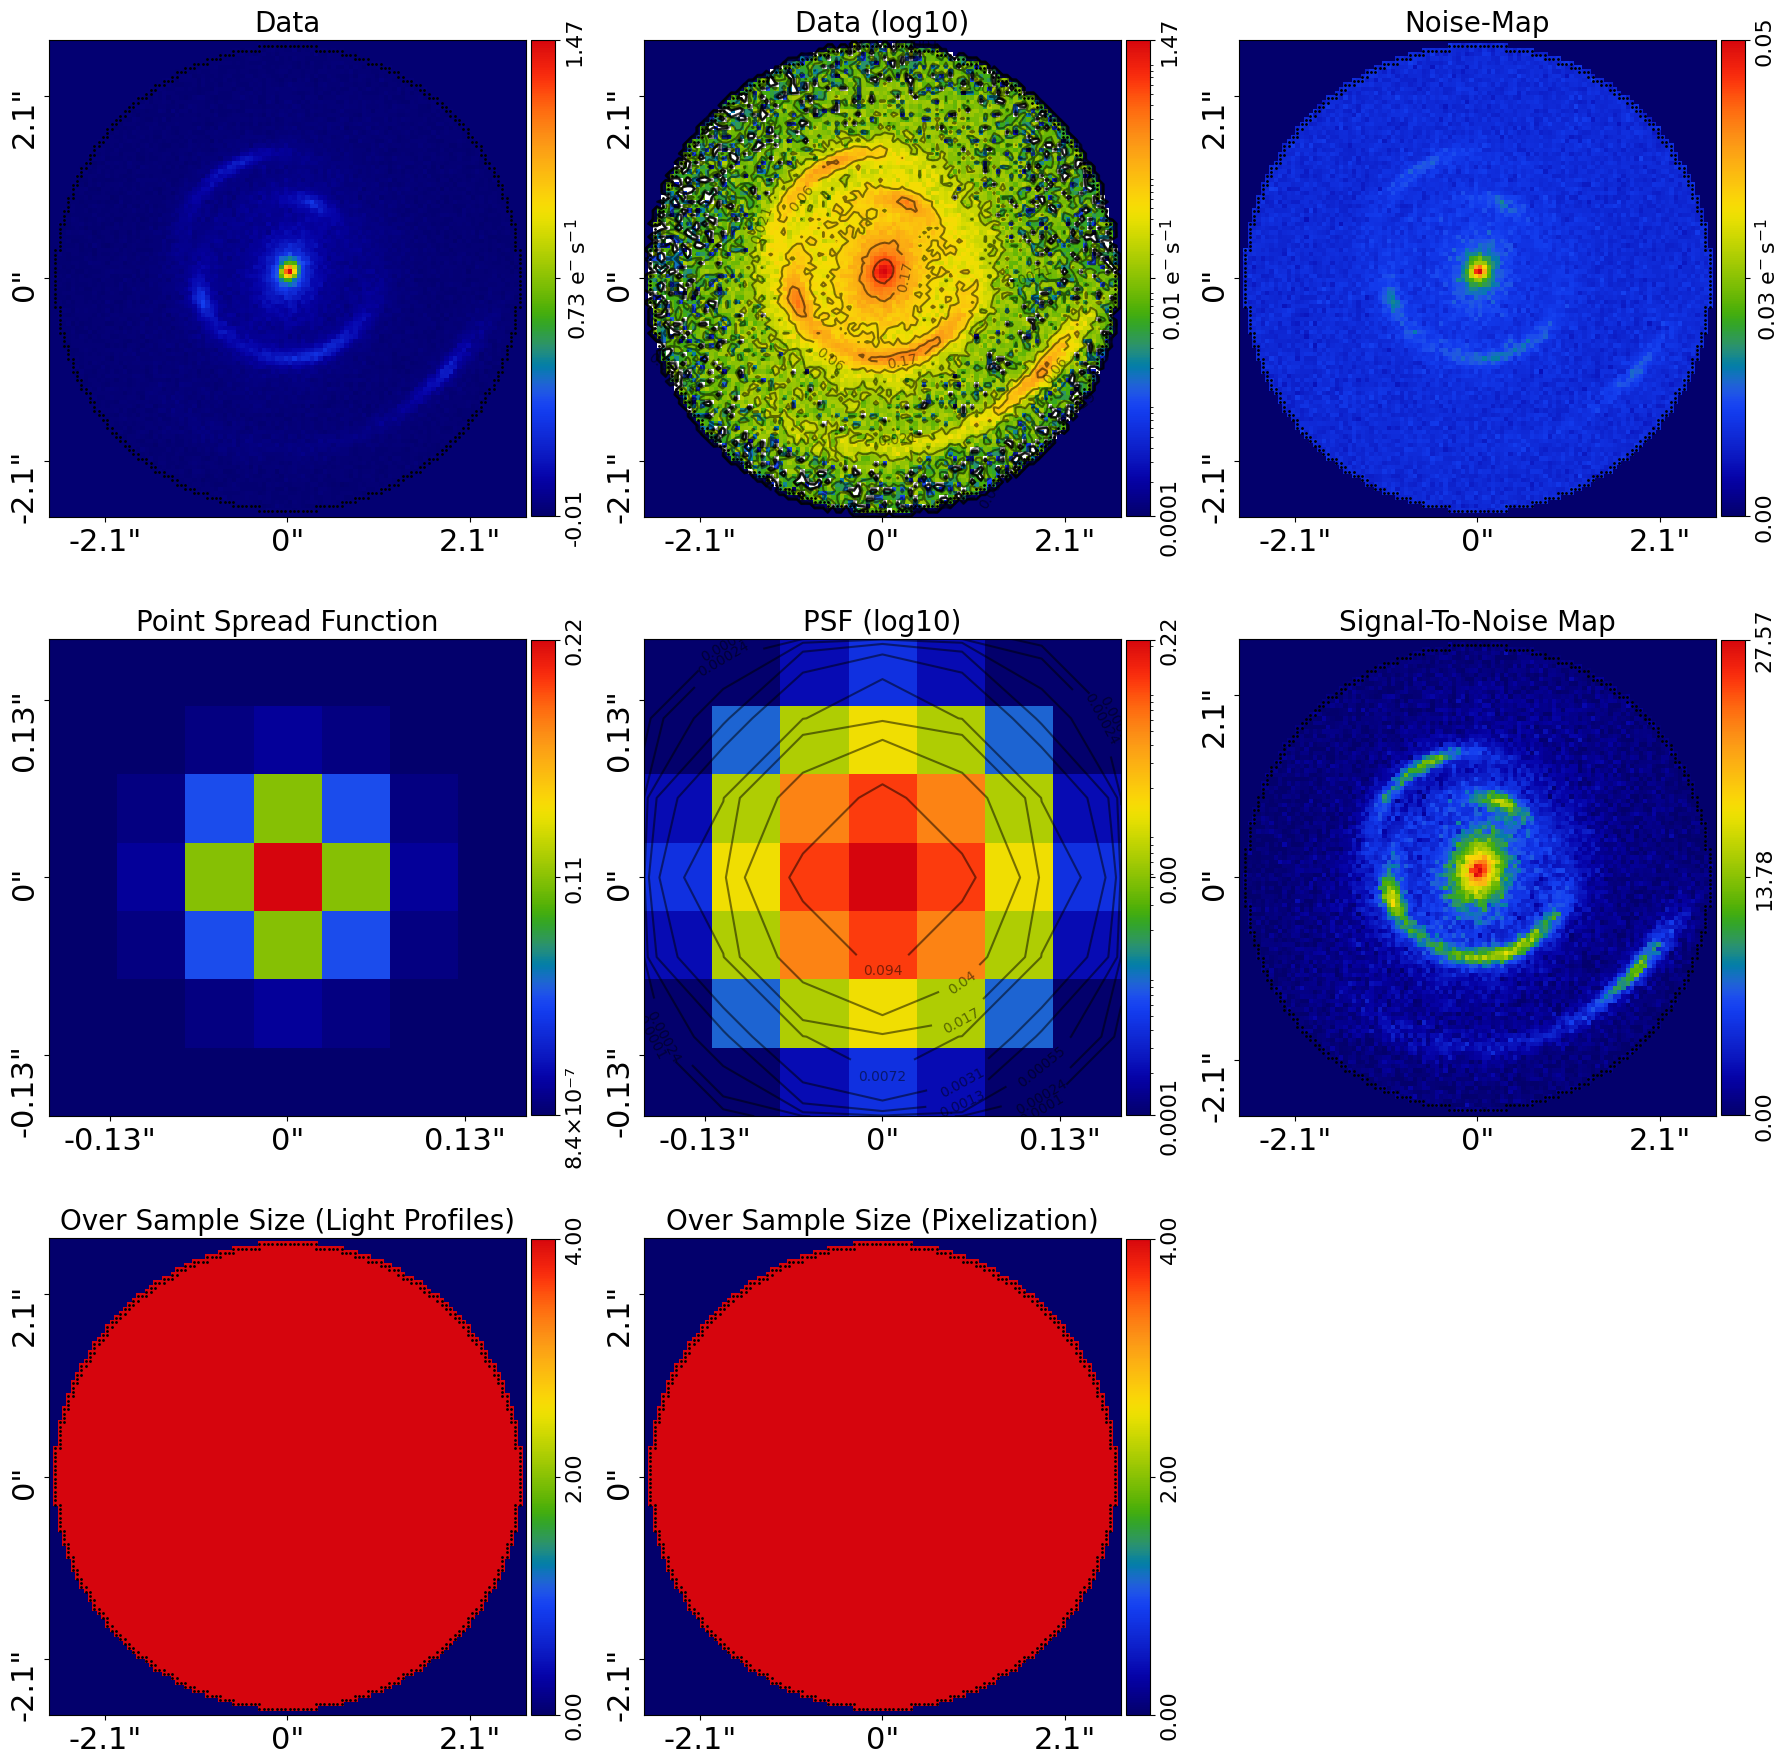

In [3]:
dataset_name = "mock_1"
dataset_path = Path("mocks")

dataset = al.Imaging.from_fits(
    data_path     = dataset_path / "mock_1_image.fits",
    noise_map_path= dataset_path / "mock_1_noise.fits",
    psf_path      = dataset_path / "mock_psf.fits",
    pixel_scales  = 0.05,
)

mask_radius = 2.7  # arcsec
mask = al.Mask2D.circular(
    shape_native = dataset.shape_native,
    pixel_scales = dataset.pixel_scales,
    radius       = mask_radius,
)
dataset = dataset.apply_mask(mask=mask)

aplt.subplot_imaging_dataset(dataset=dataset)

## 2. Image positions (anchor the ray-tracing)

Two sets of multiply-imaged features are visible in the data — one per source-plane arc system. Recording them explicitly gives Nautilus a positions-likelihood term (`al.PositionsLH`) that rejects implausibly offset mass models even when the image residuals are small elsewhere.

The positions below are hand-measured from the mock image (same values as the method paper notebook):

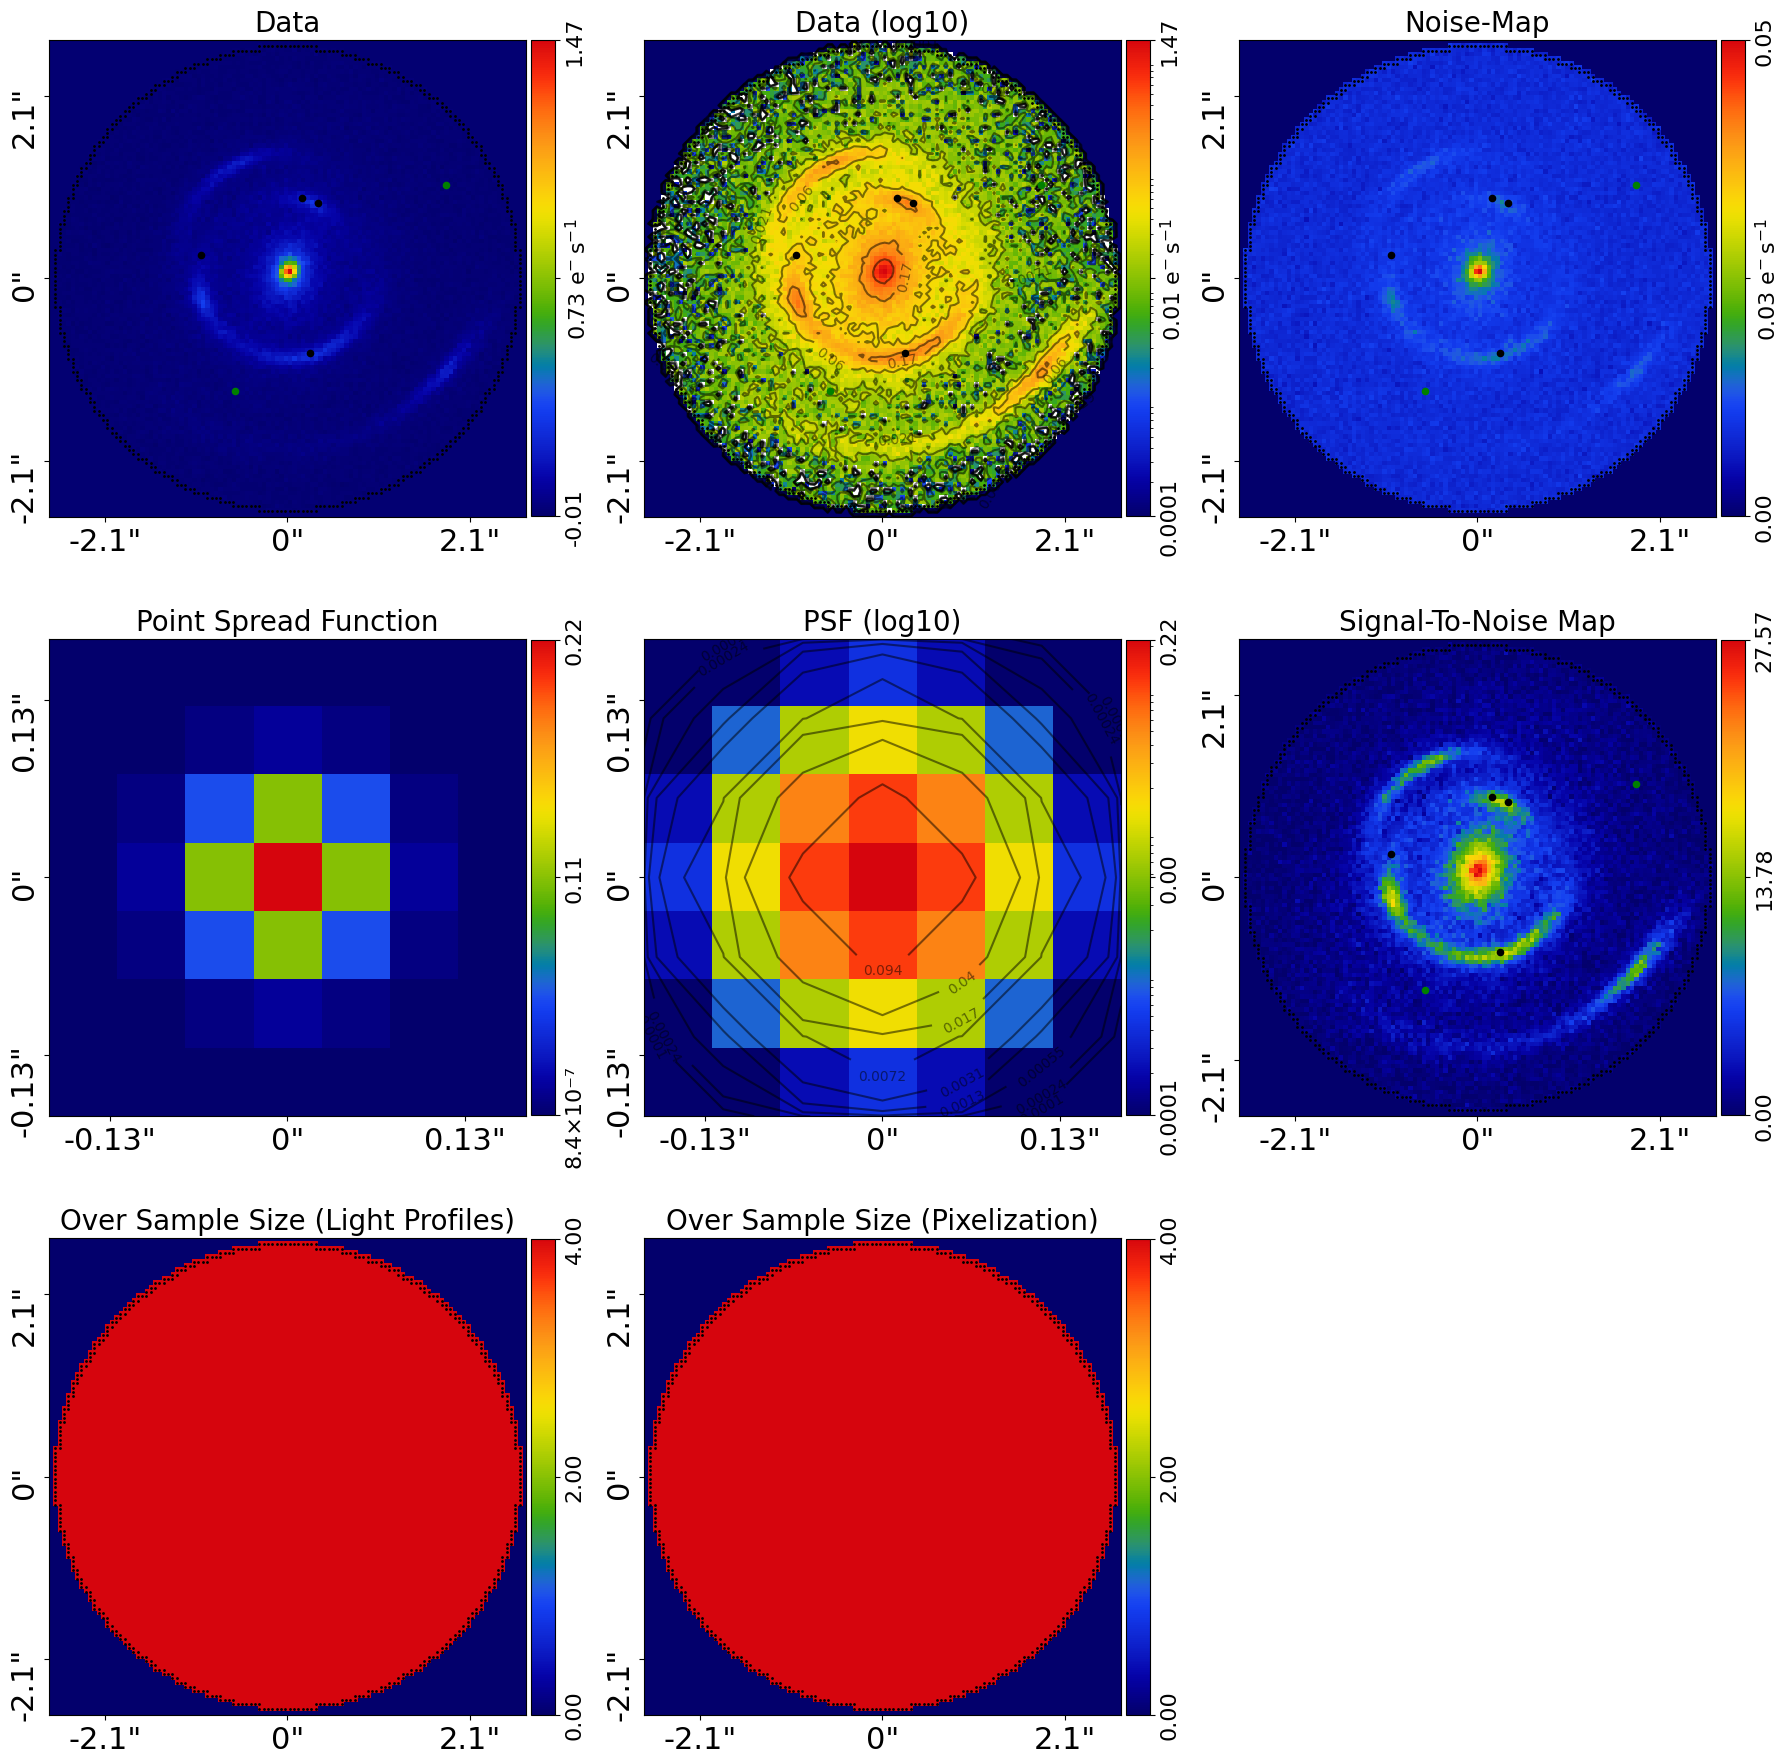

Set A: [array([0.93, 0.17]), array([0.87, 0.35]), array([ 0.27, -1.  ]), array([-0.86,  0.26])]
Set B: [array([1.08, 1.83]), array([-1.3, -0.6])]


In [4]:
positions_A = al.Grid2DIrregular(
    values=[(0.93, 0.17), (0.87, 0.35), (0.27, -1.0), (-0.86, 0.26)]
)
positions_B = al.Grid2DIrregular(
    values=[(1.08, 1.83), (-1.3, -0.6)]
)

# aplt.subplot_imaging_dataset accepts `positions=` directly in 2026.4 —
# pass a list of Grid2DIrregular to overlay multiple image systems.
aplt.subplot_imaging_dataset(dataset=dataset, positions=[positions_A, positions_B])

print("Set A:", list(positions_A))
print("Set B:", list(positions_B))

---

## 3. Model composition (native multi-plane)

Three galaxies at three redshifts. `al.Tracer` groups them into planes and does proper plane-to-plane ray-tracing automatically.

Priors are informed by *knowing the truth values* of the simulation. For a real system you'd replace these with:
- light-model parameters from a *free* pre-fit of the lens light alone (with the arc masked),
- an Einstein-radius prior from a rough SIS estimate using the image separation,
- a source-centre prior derived from ray-tracing a roughly-right mass model.

The priors below are *wide enough to allow posterior exploration* but *narrow enough to block the rotational mirror-image mode* that we documented in Mod 04 (see the four failure patterns in `memory/project_fit_failure_patterns.md`).

In [5]:
# ---- Primary lens (z = 0.5) ---------------------------------
bulge_0 = af.Model(al.lp.Sersic)
mass_0  = af.Model(al.mp.Isothermal)

# Tie bulge centre to mass centre (physical: stars + mass share a centre of
# potential for an isolated galaxy).
mass_0.centre.centre_0  = af.UniformPrior(lower_limit=-0.1, upper_limit=0.1)
mass_0.centre.centre_1  = af.UniformPrior(lower_limit=-0.1, upper_limit=0.1)
bulge_0.centre.centre_0 = mass_0.centre.centre_0
bulge_0.centre.centre_1 = mass_0.centre.centre_1

# Informative priors. For a real lens, derive these from a free light-only
# pre-fit with the arc masked.
bulge_0.ell_comps.ell_comps_0 = af.TruncatedGaussianPrior(
    mean=0.33, sigma=0.15, lower_limit=-1.0, upper_limit=1.0)
bulge_0.ell_comps.ell_comps_1 = af.TruncatedGaussianPrior(
    mean=0.00, sigma=0.15, lower_limit=-1.0, upper_limit=1.0)
bulge_0.effective_radius = af.TruncatedGaussianPrior(
    mean=1.0, sigma=0.5, lower_limit=0.01, upper_limit=5.0)
bulge_0.sersic_index     = af.TruncatedGaussianPrior(
    mean=3.0, sigma=0.8, lower_limit=0.5, upper_limit=6.0)

mass_0.ell_comps.ell_comps_0 = af.TruncatedGaussianPrior(
    mean=0.33, sigma=0.2, lower_limit=-1.0, upper_limit=1.0)
mass_0.ell_comps.ell_comps_1 = af.TruncatedGaussianPrior(
    mean=0.00, sigma=0.2, lower_limit=-1.0, upper_limit=1.0)
mass_0.einstein_radius       = af.TruncatedGaussianPrior(
    mean=1.6, sigma=0.2, lower_limit=0.3, upper_limit=3.0)

shear = af.Model(al.mp.ExternalShear)

lens_0 = af.Model(al.Galaxy, redshift=0.5,
                  bulge=bulge_0, mass=mass_0, shear=shear)

# ---- Secondary lens (z = 0.8) -------------------------------
# No external shear on the secondary — one shear term per system is enough;
# adding two creates a perfectly degenerate pair.
bulge_1 = af.Model(al.lp.Sersic)
mass_1  = af.Model(al.mp.Isothermal)

mass_1.centre.centre_0  = af.UniformPrior(lower_limit=-0.1, upper_limit=0.1)
mass_1.centre.centre_1  = af.UniformPrior(lower_limit=-0.1, upper_limit=0.1)
bulge_1.centre.centre_0 = mass_1.centre.centre_0
bulge_1.centre.centre_1 = mass_1.centre.centre_1

bulge_1.effective_radius = af.TruncatedGaussianPrior(
    mean=1.0, sigma=0.5, lower_limit=0.01, upper_limit=5.0)
bulge_1.sersic_index     = af.TruncatedGaussianPrior(
    mean=3.0, sigma=0.8, lower_limit=0.5, upper_limit=6.0)
mass_1.einstein_radius   = af.TruncatedGaussianPrior(
    mean=1.0, sigma=0.2, lower_limit=0.1, upper_limit=3.0)

lens_1 = af.Model(al.Galaxy, redshift=0.8,
                  bulge=bulge_1, mass=mass_1)

# ---- Source (z = 1.7) --------------------------------------
# SersicCore handles a cuspy inner profile better than a plain Sersic near
# the arc.
bulge_src = af.Model(al.lp.SersicCore)
bulge_src.centre.centre_0   = af.UniformPrior(lower_limit=-0.2, upper_limit=0.2)
bulge_src.centre.centre_1   = af.UniformPrior(lower_limit=-0.2, upper_limit=0.2)
bulge_src.effective_radius  = af.TruncatedGaussianPrior(
    mean=0.2, sigma=0.15, lower_limit=0.01, upper_limit=1.5)
bulge_src.sersic_index      = af.TruncatedGaussianPrior(
    mean=2.0, sigma=0.8, lower_limit=0.5, upper_limit=6.0)

source = af.Model(al.Galaxy, redshift=1.7, bulge=bulge_src)

# ---- Combine ------------------------------------------------
model = af.Collection(galaxies=af.Collection(
    lens_0 = lens_0,
    lens_1 = lens_1,
    source = source,
))

print(f"Total free parameters: {model.total_free_parameters}")
print(f"Redshift planes: {sorted({0.5, 0.8, 1.7})}")

Total free parameters: 29
Redshift planes: [0.5, 0.8, 1.7]


---

## 4. Run the fit (skip-guard pattern)

Nautilus on ~25 free parameters at `n_live=250` is multi-hour on a laptop. The same skip-guard pattern from Mod 04/05 applies:
- If `results/compound_direct_fit/summary.json` already exists (from a prior Cannon run), skip the fit and load the committed artifact.
- To force a local re-fit, set `LTA_RUN_HEAVY=1` in the environment and restart the kernel.
- For a fresh cluster run, submit `fit_example_compound_lens.py` via `Modules/10_Cluster_Computing/`.

In [6]:
_HAVE_RESULTS = (RESULTS_ROOT / "compound_direct_fit" / "summary.json").exists()
_FORCE_RUN    = os.environ.get("LTA_RUN_HEAVY", "").lower() in ("1", "true", "yes")

if _HAVE_RESULTS and not _FORCE_RUN:
    print("[local] Using committed Cannon results — skipping the fit.")
    print("[local] Set LTA_RUN_HEAVY=1 to force a re-fit (or submit on Cannon).")
    result = None
    search = None
    analysis = None
elif not _HAVE_RESULTS and not _FORCE_RUN:
    print("[local] No committed results for compound_direct_fit yet.")
    print("[local] Set LTA_RUN_HEAVY=1 to run locally (~hours) or submit on")
    print("[local] Cannon via `fit_example_compound_lens.py`.")
    result = None
    search = None
    analysis = None
else:
    # Positions likelihood — reject models whose multiple images miss the
    # hand-measured positions by more than `threshold` arcsec.
    positions_lh = al.PositionsLH(
        positions=[positions_A, positions_B], threshold=0.1)

    analysis = al.AnalysisImaging(
        dataset=dataset,
        positions_likelihood_list=[positions_lh],
        use_jax=False,
    )

    search = af.Nautilus(
        path_prefix             = Path("output") / "compound_lens",
        name                    = "compound_direct_fit",
        unique_tag              = dataset_name,
        n_live                  = 250,
        n_batch                 = 50,
        iterations_per_update   = 30000,
        number_of_cores         = int(os.environ.get("SLURM_CPUS_PER_TASK", "1")),
    )

    result = search.fit(model=model, analysis=analysis)
    print("\n[local] Fit complete.")
    print(result.info)

[local] No committed results for compound_direct_fit yet.
[local] Set LTA_RUN_HEAVY=1 to run locally (~hours) or submit on
[local] Cannon via `fit_example_compound_lens.py`.


## 5. Visualise the result

Branch on whether we have a live result object or need to fall back to the committed Cannon artifact.

In [7]:
if result is not None:
    aplt.subplot_fit_imaging(fit=result.max_log_likelihood_fit)
else:
    show_result("compound_direct_fit")

(no results for stage 'compound_direct_fit' yet — run on Cannon or set LTA_RUN_HEAVY=1)


---

## 6. `/autolens-fit-diagnostics` audit

Applying the **Module 11 physical bar** (six mandatory panels, plus the numerical threshold) to this fit.

> **Verdict template** — fill in after reading the panels above.
>
> ```
> Verdict:  [ PASS | SUSPECT | FAIL ]
>
> Numeric summary
>   chi²/N:           __.___          (bar: ≤1.3 pass, ≥2.0 fail)
>   max |res|:        ___.__ σ         (bar: ≤4σ pass, ≥6σ fail)
>   log_Z:            ___,___
>   free params:      ___
>
> Panel walk
>   1. Residual map:        ____________
>   2. Residual map 1σ:     ____________
>   3. Chi² map:            ____________ (hot spots on the arc? at lens 0? at lens 1?)
>   4. Source Plane (Zoomed): ____________  [caustic size ____ ", no corner pixels?]
>   5. Lens Light Subtracted: ____________ (residual at z=0.5 centre? at z=0.8 centre?)
>   6. model_results.txt:   ____________ (posterior pinned at any prior rail?)
> ```

### What a passing compound fit looks like

- **Two separate lens-light residuals** should subtract cleanly — one each at the z=0.5 and z=0.8 galaxy centres. Failure mode: *one* of them doesn't subtract, meaning the fit chose to put all the light at one deflector's centre.
- **Source plane** should show a smooth Sersic/SersicCore blob well inside its tangential caustic — NOT a collapsed single-pixel spike. Pattern-6 mesh collapse is impossible here because the source is parametric, but a *Sersic* source can still converge to an unphysically tiny R_e if the arc is being fitted by mass-model artefacts instead of source emission.
- **log_Z** should be within a few hundred of the value Nautilus reported on the *same data* for a single-lens model — if this compound fit has log_Z catastrophically worse than the one-lens fit, the secondary lens is poisoning the posterior rather than helping.

---

## 7. Exercises

### Exercise 1 — Sensitivity to positions-likelihood threshold
Re-fit with `PositionsLH(threshold=0.5)` (loose) and `threshold=0.03` (tight). How does the posterior on the secondary lens's Einstein radius shift? What fraction of Nautilus-proposed models are rejected by the positions term at each threshold?

### Exercise 2 — Isothermal → PowerLaw per deflector
Swap `al.mp.Isothermal` for `al.mp.PowerLaw` on *just* the primary lens. Is the recovered density slope $\gamma'$ significantly different from 2.0? Now do the same on *just* the secondary. Does the primary slope shift when you add the secondary's freedom? (This is the Section-1 stability test from Module 11 applied to compound systems.)

### Exercise 3 — Redshift sensitivity
Holding all mass parameters at their best-fit values, vary `z_2` (the secondary lens redshift) from 0.6 to 1.0 and recompute the model image. How far off can you be in `z_2` before the image residuals visibly degrade? This is the real-world question: your photo-z for the intermediate deflector may have 10–15% uncertainty.

### Exercise 4 — Compare with the SLaM variant
Read `02_compound_slam.ipynb`, then compare the log_Z and wall-clock cost of the direct fit here against the staged-SLaM variant. Which converges faster? Which gives tighter posteriors on individual mass parameters? Write a short paragraph on *when* you'd use each.

---

## Summary

- Compound lensing with `al.Tracer` is trivial *once the model is composed correctly* — pass galaxies at different redshifts and ray-tracing is recursive and correct.
- The *real* work is **prior placement**: with ~25 free parameters, Nautilus has more dimensions than the posterior volume is informative over. Informative priors (centre ranges, Einstein-radius estimates, effective-radius and sersic-index Gaussians) are what keep the search tractable.
- The `al.PositionsLH` term is a dominant likelihood penalty for compound lenses because it fires on both image systems simultaneously — a rotational mirror mode that fits the z=0.5 arc but misses the z=1.7 arc images is penalised sharply.
- The skill-audit template doesn't change from Mod 11 — the six diagnostic panels work the same for 1-, 2-, or N-deflector systems. You just have to check for two centre residuals in the Lens Light Subtracted panel instead of one.

**Next:** `02_compound_slam.ipynb` for the staged-chain variant and the single-effective-deflector simplification.

---

*Learning to Autolens — Examples / compound_lens / 01*  
*Rodrigo Córdova Rosado, Harvard CfA*